Train: (1447, 22)
Test: (366, 22)
MAE: 125.44262676134785
RMSE: 145.22213452546828
R2: -0.022588073465222847
Accuracy: 18.579234972677597
Category Accuracy: 21.311475409836063


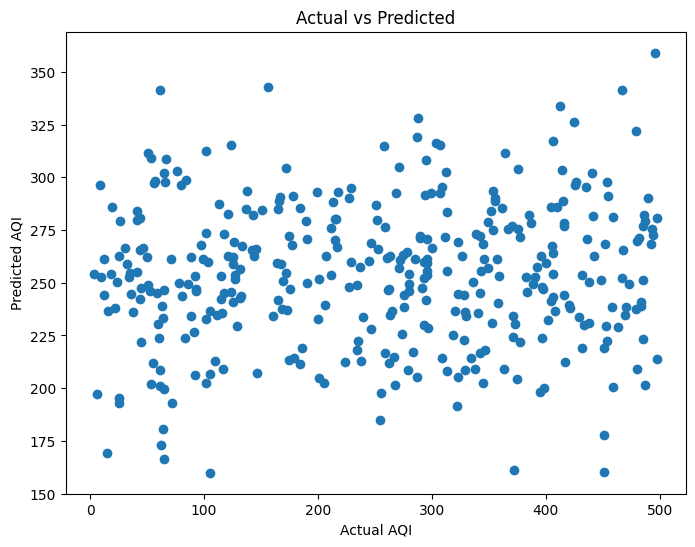

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# LOAD
df = pd.read_csv("../data/cleaned_aqi_final.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# FEATURES
df['AQI_lag1'] = df['AQI'].shift(1)
df['AQI_lag2'] = df['AQI'].shift(2)
df['AQI_lag3'] = df['AQI'].shift(3)
df['AQI_lag7'] = df['AQI'].shift(7)
df['AQI_lag14'] = df['AQI'].shift(14)

df['PM25_roll3'] = df['PM2.5'].rolling(3).mean()
df['PM25_roll7'] = df['PM2.5'].rolling(7).mean()

df['PM10_roll3'] = df['PM10'].rolling(3).mean()
df['PM10_roll7'] = df['PM10'].rolling(7).mean()

df['month'] = df['Date'].dt.month
df['dayofweek'] = df['Date'].dt.dayofweek

df = df.dropna()

features = [
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'Benzene',
    'Toluene',
    'AQI_lag1',
    'AQI_lag2',
    'AQI_lag3',
    'AQI_lag7',
    'AQI_lag14',
    'PM25_roll3',
    'PM25_roll7',
    'PM10_roll3',
    'PM10_roll7',
    'month',
    'dayofweek'
]

# TIME SPLIT
train_df = df[df['Date'] < '2024-01-01']
test_df = df[df['Date'] >= '2024-01-01']

X_train = train_df[features]
y_train = train_df['AQI']

X_test = test_df[features]
y_test = test_df['AQI']

print("Train:", X_train.shape)
print("Test:", X_test.shape)

# MODEL
model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=10,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

# METRICS
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# ACCURACY
error = np.abs(y_test.values - pred)

accuracy = (np.sum(error <= 50) / len(error)) * 100

print("Accuracy:", accuracy)

# CATEGORY
def get_category(aqi):
    if aqi <= 50:
        return 0
    elif aqi <= 100:
        return 1
    elif aqi <= 200:
        return 2
    elif aqi <= 300:
        return 3
    elif aqi <= 400:
        return 4
    else:
        return 5

actual_cat = np.array([get_category(x) for x in y_test])
pred_cat = np.array([get_category(x) for x in pred])

cat_acc = np.mean(actual_cat == pred_cat) * 100

print("Category Accuracy:", cat_acc)

# PLOT
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted")
plt.show()